# Training a MNIST Model

## Examine Data

In [1]:
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"x_train: {x_train.shape}")
print(f"y_test: {y_test.shape}")

2023-10-08 11:57:46.708712: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-10-08 11:57:46.755891: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-10-08 11:57:46.756523: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-08 11:57:47.797381: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


x_train: (60000, 28, 28)
y_test: (10000,)


In [2]:
import pandas as pd

pd.Series(y_test).describe()

count    10000.000000
mean         4.443400
std          2.895865
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max          9.000000
dtype: float64

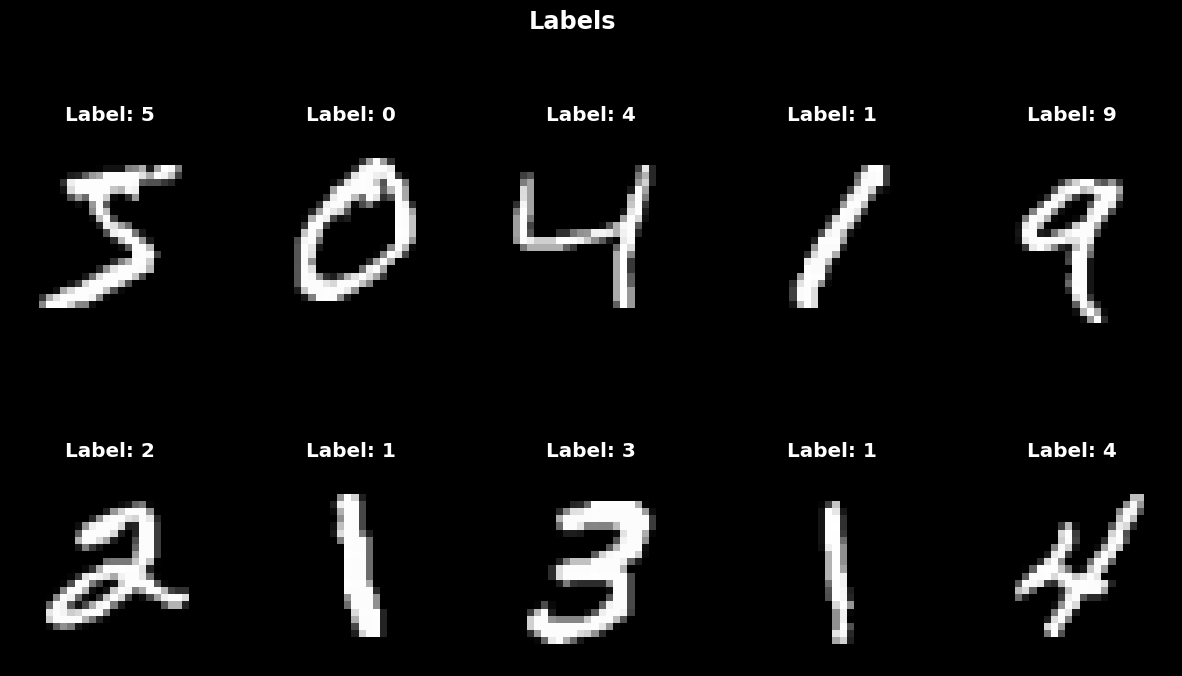

In [3]:
from data_science.util.print_images_in_subfigures import print_images_in_subfigures

print_images_in_subfigures(
    x_train[:10], y_train[:10], subtitle_prefix="Label", title="Labels"
)

## Preprocessing Data

In [4]:
x_train, x_test = x_train / 255.0, x_test / 255.0
pd.Series(x_test.ravel()).describe()

count    7.840000e+06
mean     1.325146e-01
std      3.104803e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
dtype: float64

In [5]:
import numpy as np

x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

## Train Model

In [6]:
%load_ext tensorboard
%tensorboard --logdir=./logs --port=6006

In [7]:
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(10),
    ]
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
)

history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=32,
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[
        tf.keras.callbacks.TensorBoard(log_dir="./logs"),
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    ],
)

2023-10-08 11:57:53.819877: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-10-08 11:57:53.820356: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/20
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2560 - sparse_categorical_accuracy: 0.9270 - val_loss: 0.1368 - val_sparse_categorical_accuracy: 0.9596
Epoch 2/20
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1116 - sparse_categorical_accuracy: 0.9676 - val_loss: 0.1056 - val_sparse_categorical_accuracy: 0.9670
Epoch 3/20
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0771 - sparse_categorical_accuracy: 0.9771 - val_loss: 0.0930 - val_sparse_categorical_accuracy: 0.9709
Epoch 4/20
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0569 - sparse_categorical_accuracy: 0.9825 - val_loss: 0.0814 - val_sparse_categorical_accuracy: 0.9752
Epoch 5/20
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0445 - sparse_categorical_accuracy: 0.9860 - val_loss: 0.0829 - val_sparse_categorical_accuracy: 0.9744
Epoch 6/20
1875/1875 [==============================] - 5s 2ms/step - loss: 0.0366 - spars

## Evaluation

In [8]:
model.evaluate(x=x_test, y=y_test)

313/313 [==============================] - 0s 1ms/step - loss: 0.0706 - sparse_categorical_accuracy: 0.9795


[0.07061412185430527, 0.9794999957084656]

In [12]:
y_pred = np.argmax(model.predict(x_test), axis=1)
y_pred.shape

313/313 [==============================] - 0s 869us/step


(10000,)

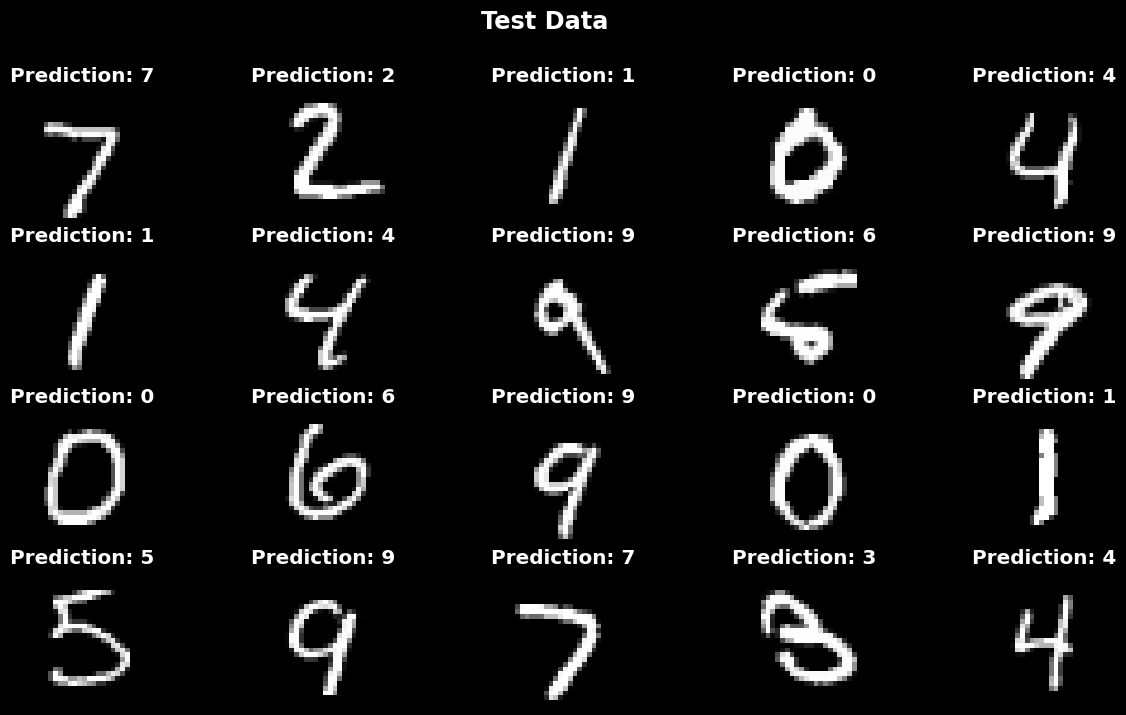

In [13]:
print_images_in_subfigures(
    images=x_test[:20],
    labels=y_pred[:20],
    subtitle_prefix="Prediction",
    title="Test Data",
)

## Save Model

In [14]:
import pathlib

model_version = "0001"
model_name = "minst_model"
model_path = pathlib.Path(model_name, model_version)
tf.saved_model.save(obj=model, export_dir=model_path)

INFO:tensorflow:Assets written to: minst_model/0001/assets


INFO:tensorflow:Assets written to: minst_model/0001/assets
